# Medical

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_train = pd.read_csv('Training.csv')
df_test = pd.read_csv("Testing.csv")

# Data Preprocessing

In [3]:
df_train.drop(columns=['Unnamed: 133'], inplace=True)

In [4]:
target = 'prognosis'
features = [col for col in df_train.columns if col != target]
x = df_train[features]
y = df_train[target]

# Data Visualization

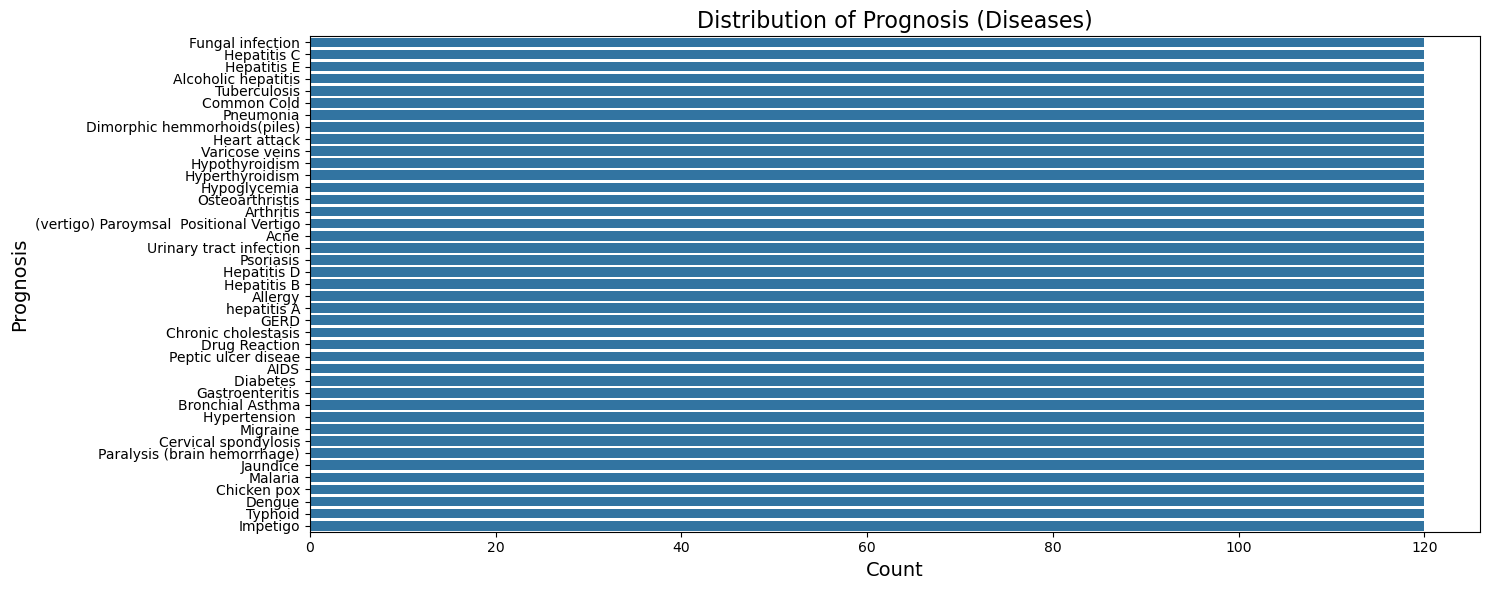

In [5]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df_train, y='prognosis', order=df_train['prognosis'].value_counts().index)
plt.title('Distribution of Prognosis (Diseases)', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Prognosis',fontsize=14)
plt.tight_layout()
plt.show()

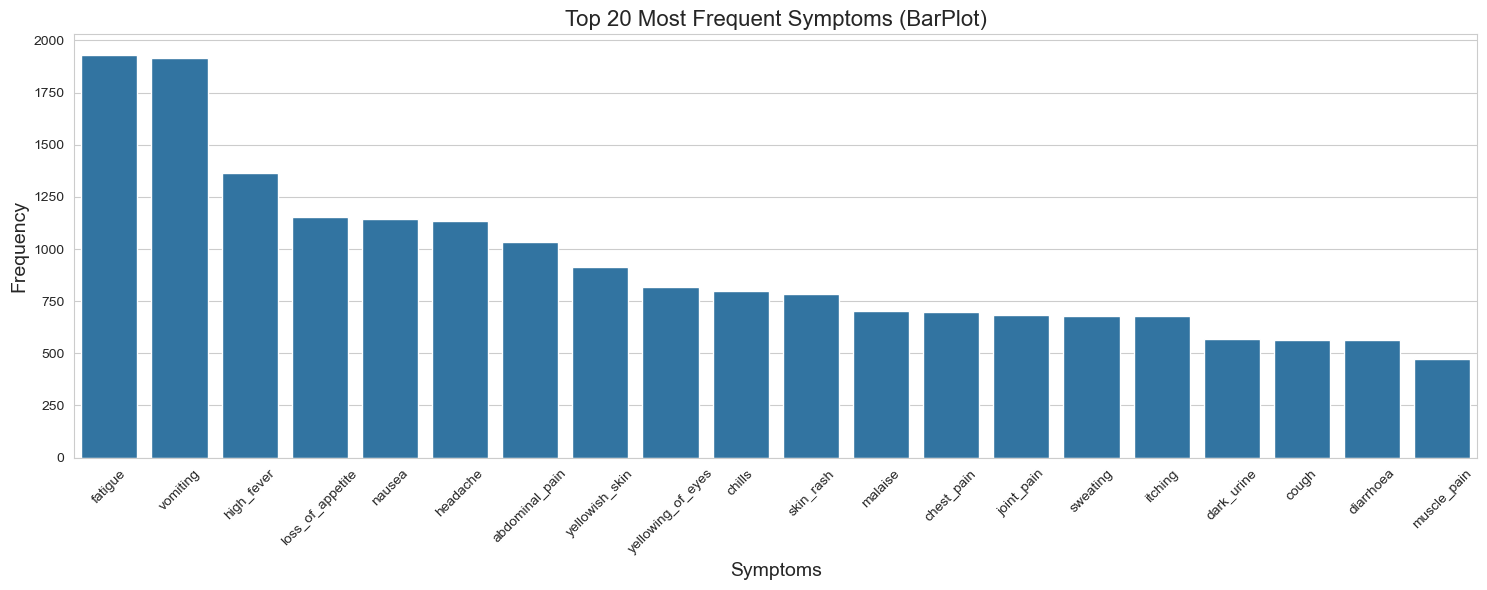

In [6]:
symptom_columns = [col for col in df_train.columns if col != 'prognosis']
symptom_counts = df_train[symptom_columns].sum().sort_values(ascending=False)

sns.set_style('whitegrid')
plt.figure(figsize=(15, 6))
sns.barplot(x=symptom_counts.index[:20], y=symptom_counts.values[:20])
plt.title('Top 20 Most Frequent Symptoms (BarPlot)', fontsize=16)
plt.xlabel('Symptoms', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

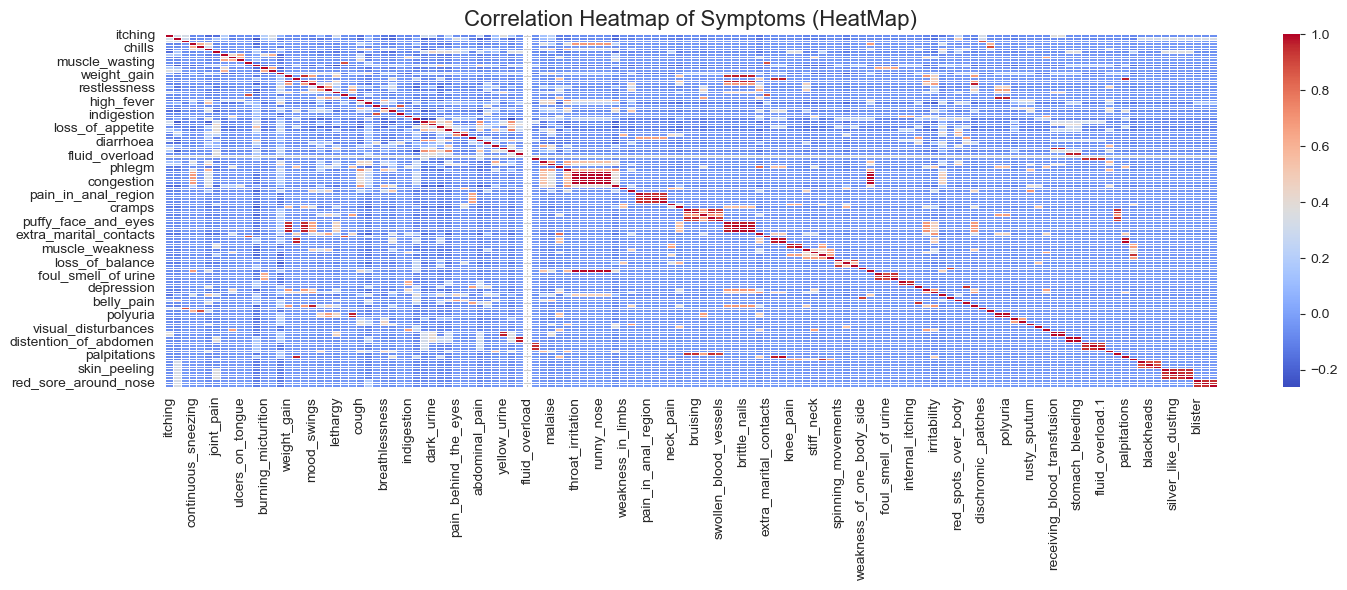

In [7]:
plt.figure(figsize=(15, 6))
corr = df_train[symptom_columns].corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Symptoms (HeatMap)', fontsize=16)
plt.tight_layout()
plt.show()

# Model Making

In [8]:
# Spliting Data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [9]:
# Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [10]:
# Extract features (symptoms) from the test dataset
x_test = df_test[symptom_columns]
# Encode the target variable (prognosis) in the test dataset using the same LabelEncoder used for training
y_test = le.transform(df_test['prognosis'])

In [11]:
# Scalling
scaler = StandardScaler()

In [12]:
# Fit the scaler on training data and transform both training and test data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [13]:
# Initialize The Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [14]:
# Prediction
y_pred = model.predict(x_test)
y_pred

array([15.  ,  4.  , 16.  ,  9.  , 14.  , 33.  ,  1.  , 12.  , 17.  ,
        6.  , 23.  , 30.  ,  7.  , 32.  , 28.  , 29.  ,  8.  , 11.  ,
       37.  , 40.  , 19.  , 20.  , 21.  , 22.  ,  3.  , 36.  , 10.  ,
       34.  , 13.  , 18.  , 39.  , 26.  , 24.  , 25.  , 31.  ,  5.  ,
        0.  ,  2.  , 38.  , 35.  , 27.  , 19.72])

In [15]:
# Cecking Score
model.score(x_test, y_test)

0.9961351777121497

In [16]:
# Evaluate Model Performence
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [17]:
# Print The Result
print(f'Mean Absolute Error: {mae:.2f}%')
print(f'Mean Squared Error: {mse:.2f}%')
print(f'R² Score: {r2:.2f}%')

Mean Absolute Error: 0.11%
Mean Squared Error: 0.53%
R² Score: 1.00%


# Conclusion
# Key steps include data preprocessing, visualization, and predictive modeling using a Random Forest Regressor. The approach effectively encodes categorical variables, scales numerical data, and evaluates the model using metrics like RMSE and R² score. The use of data visualization aids in understanding feature distributions and relationships. Overall, the model aims to predict medical outcomes with reasonable accuracy, showcasing a standard yet effective workflow for applied medical data science.